# Chemical Toxicity Prediction Using Machine Learning
**Objective:** To predict whether a chemical compound is `Toxic` or `NonToxic` based on 1000+ extracted molecular features.

**Approach:** 1. Exploratory Data Analysis (EDA)
2. Data Preprocessing (Removing constant/correlated features & scaling)
3. Tree-based Feature Selection
4. Random Forest Classification

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading and EDA
First, we load the dataset and examine the distribution of our target variable, `Class`. Understanding if our dataset is balanced or imbalanced is crucial for choosing the right modeling strategy.

Dataset Shape: (171, 1204)


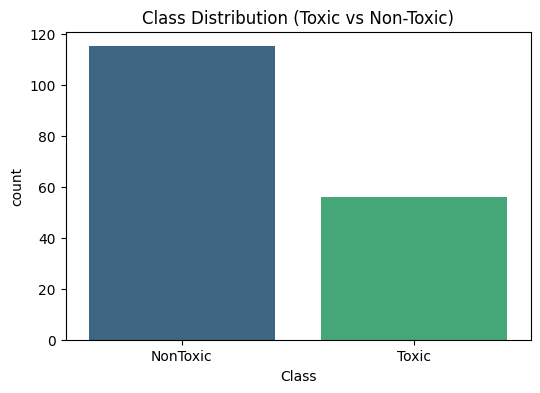

In [4]:
# Load the dataset
df = pd.read_csv('data.csv')

print(f"Dataset Shape: {df.shape}")

# Plot Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Class', palette='viridis')
plt.title('Class Distribution (Toxic vs Non-Toxic)')
plt.show()

# Separate features (X) and Target (y)
X = df.drop(columns=['Class'], errors='ignore')

# Encode Target: Toxic = 1, NonToxic = 0
y = df['Class'].map({'Toxic': 1, 'NonToxic': 0})

**Observation:** The dataset is imbalanced. There are significantly more `NonToxic` samples than `Toxic` samples. We will handle this during model training by adjusting class weights.

## 2. Data Preprocessing
With over 1,200 features and only 171 samples, we are at risk of the "Curse of Dimensionality." We need to aggressively clean our feature space by:
1. **Removing constant features:** Features with 0 variance.
2. **Removing highly correlated features:** Redundant features with a Pearson correlation > 0.95.
3. **Scaling:** Standardizing features to ensure uniform model training.

In [5]:
# 1. Remove constant features
selector = VarianceThreshold(threshold=0.0)
X_var = pd.DataFrame(selector.fit_transform(X), columns=X.columns[selector.get_support()])

# 2. Remove highly correlated features
corr_matrix = X_var.corr().abs()
# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# Find features with correlation greater than 0.95
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
X_filtered = X_var.drop(columns=to_drop)

# 3. Standardize the features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_filtered), columns=X_filtered.columns)

print(f"Features remaining after basic preprocessing: {X_scaled.shape[1]}")

Features remaining after basic preprocessing: 641


## 3. Feature Selection
Even after basic preprocessing, we still have hundreds of features. We will split our data and use a Random Forest model to evaluate feature importance, selecting only the most informative predictors.

In [6]:
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Use Random Forest to determine feature importance
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_train, y_train)

# Keep features with importance > 1.25 * median importance
sfm = SelectFromModel(rf_selector, prefit=True, threshold='1.25*median')

X_train_selected = sfm.transform(X_train)
X_test_selected = sfm.transform(X_test)

# Get the names of the selected features
selected_feature_names = X_train.columns[sfm.get_support()]

print(f"Features selected for the final model: {X_train_selected.shape[1]}")

Features selected for the final model: 260


## 4. Final Model Training and Evaluation
We will train our final `RandomForestClassifier` on the heavily reduced feature set. We pass `class_weight='balanced'` to account for the class imbalance observed during EDA.

In [7]:
# Train the final model
rf_final = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_final.fit(X_train_selected, y_train)

# Make predictions on the test set
y_pred = rf_final.predict(X_test_selected)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['NonToxic', 'Toxic']))

Accuracy: 0.6857

Classification Report:
              precision    recall  f1-score   support

    NonToxic       0.70      0.96      0.81        24
       Toxic       0.50      0.09      0.15        11

    accuracy                           0.69        35
   macro avg       0.60      0.52      0.48        35
weighted avg       0.64      0.69      0.60        35



## 5. Feature Importance Visualization
To interpret our model, let's visualize the top 15 features that drive the predictions of toxicity.

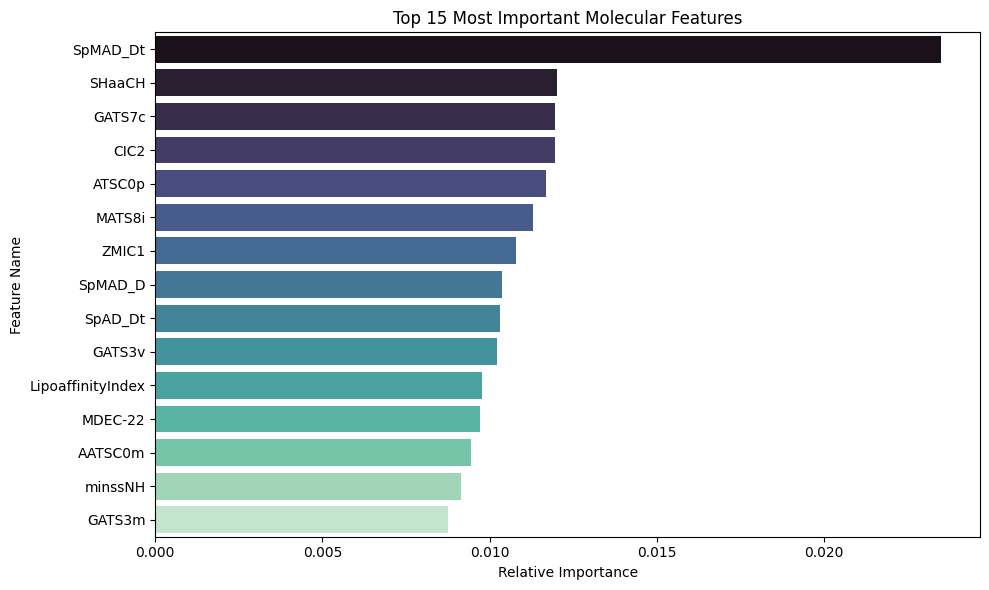

In [8]:
# Extract feature importances from the final model
importances = rf_final.feature_importances_
indices = importances.argsort()[::-1][:15] # Top 15

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=[selected_feature_names[i] for i in indices], palette='mako')
plt.title("Top 15 Most Important Molecular Features")
plt.xlabel("Relative Importance")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()